# Análisis Exploratorio de Datos (EDA)

En esta etapa se realiza un análisis exploratorio del conjunto de datos de sismos registrados por el USGS en el área de estudio. El objetivo es conocer la estructura y características de los datos, identificar posibles valores faltantes, inconsistencias y variables relevantes, y explorar su comportamiento mediante estadísticas y visualizaciones.

Los resultados obtenidos en esta etapa servirán como base para definir posteriormente las transformaciones y decisiones de preparación del conjunto de datos.


# 1. Importación de librerías

In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import requests
from shapely.geometry import Polygon
from io import StringIO


# 2. Obtención y carga de datos

Los datos se descargan desde la API pública de USGS, que permite consultar su catálogo de sismos filtrando por fecha y por ubicación. Los parámetros de la consulta son:

- **Período:** del 15/09/2016 al 15/09/2026 (diez años).
- **Área:** un rectángulo entre las latitudes 90° S y 21,7° S y las longitudes 75° O y 25° O. Cubre todo el territorio argentino, incluido el sector antártico. Como es un rectángulo, también incluye zonas de países vecinos y del océano, que se descartan en la sección 3.
- **Límite:** hasta 20.000 eventos, suficiente para no perder registros del período.

La respuesta llega en formato CSV y se carga en un DataFrame.

In [2]:
# Importo los datos

url = "https://earthquake.usgs.gov/fdsnws/event/1/query"

params = {
    "format": "csv",
    "starttime": "2016-09-15",
    "endtime": "2026-09-15",
    "minlatitude": -90,
    "maxlatitude": -21.7,
    "minlongitude": -75,
    "maxlongitude": -25,
    "limit": 20000
}

response = requests.get(url, params=params)
response.raise_for_status()



In [3]:
# DataFrame

df = pd.read_csv(StringIO(response.text))

## Análisis superficial de los datos para verificar su integridad.

In [4]:
print("Filas:", df.shape[0])
print("Columnas:", df.shape[1])


Filas: 10795
Columnas: 22


In [5]:
pd.set_option('display.max_columns', None)

df.head(3)

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,net,id,updated,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource
0,2026-09-14T05:03:12.877Z,-24.1313,-66.9986,189.041,4.4,mb,35.0,77.0,2.572,0.66,us,us7000than,2026-09-14T06:21:54.040Z,"69 km W of San Antonio de los Cobres, Argentina",earthquake,3.33,13.010,0.149,13.0,reviewed,us,us
1,2026-09-13T19:40:25.496Z,-26.1509,-66.6119,10.000,4.7,mb,46.0,54.0,2.863,0.78,us,us7000th7y,2026-09-24T17:19:43.040Z,"64 km W of Cafayate, Argentina",earthquake,6.25,1.889,0.088,39.0,reviewed,us,us
2,2026-09-13T12:36:14.144Z,-33.3311,-72.5473,10.000,3.9,mwr,40.0,77.0,0.815,1.02,us,us7000th65,2026-09-13T13:08:44.040Z,"90 km WNW of Cartagena, Chile",earthquake,4.36,1.839,0.053,34.0,reviewed,us,us


Cada fila del conjunto de datos corresponde a un sismo. A continuación se describe el significado de cada variable según la [documentación de USGS](https://earthquake.usgs.gov/data/comcat/data-eventterms.php), junto con su unidad de medida cuando corresponde.

| Variable          | Descripción                                                                                                                                                   | Unidad             |
| ----------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------- | ------------------ |
| `time`            | Fecha y hora en que ocurrió el evento (UTC).                                                                                                                  | —                  |
| `latitude`        | Latitud del epicentro. Valores negativos indican el hemisferio sur.                                                                                           | grados (°)         |
| `longitude`       | Longitud del epicentro. Valores negativos indican oeste de Greenwich.                                                                                         | grados (°)         |
| `depth`           | Profundidad del hipocentro, es decir, del punto donde se origina la ruptura.                                                                                  | km                 |
| `mag`             | Magnitud del evento, medida relacionada con el tamaño del sismo.                                                                                              | —                  |
| `magType`         | Método o escala con que se calculó la magnitud (`mb` = ondas de cuerpo, `mww` = magnitud de momento fase W, `ml` = magnitud local, etc.).                     | —                  |
| `nst`             | Cantidad de estaciones sísmicas usadas para localizar el evento.                                                                                              | n.º de estaciones  |
| `gap`             | Brecha azimutal: el mayor ángulo entre dos estaciones vecinas vistas desde el epicentro. Cuanto menor es este valor, mejor es la cobertura de las estaciones. | grados (°)         |
| `dmin`            | Distancia horizontal entre el epicentro y la estación más cercana (1° ≈ 111,2 km).                                                                            | grados (°)         |
| `rms`             | Error de ajuste entre los tiempos de llegada observados y los calculados. Cuanto menor es este valor, menor es la discrepancia entre ambos.                   | segundos (s)       |
| `net`             | Red sísmica que aportó la solución preferida del evento.                                                                                                      | —                  |
| `id`              | Identificador único del evento.                                                                                                                               | —                  |
| `updated`         | Fecha y hora de la última actualización del registro.                                                                                                         | fecha y hora (UTC) |
| `place`           | Descripción textual de la ubicación del evento.                                                                                                               | —                  |
| `type`            | Tipo de evento (sismo, explosión de cantera, etc.).                                                                                                           | —                  |
| `horizontalError` | Incertidumbre de la ubicación horizontal.                                                                                                                     | km                 |
| `depthError`      | Incertidumbre asociada a la profundidad.                                                                                                                      | km                 |
| `magError`        | Incertidumbre asociada a la magnitud.                                                                                                                         | —                  |
| `magNst`          | Cantidad de estaciones usadas para calcular la magnitud.                                                                                                      | n.º de estaciones  |
| `status`          | Estado de revisión del evento: `automatic` o `reviewed` (revisado por un sismólogo).                                                                          | —                  |
| `locationSource`  | Red que calculó la ubicación del evento.                                                                                                                      | —                  |
| `magSource`       | Red que calculó la magnitud del evento.                                                                                                                       | —                  |

Las variables `nst`, `gap`, `dmin`, `rms`, `horizontalError`, `depthError`, `magError` y `magNst` corresponden a **variables de calidad**, ya que aportan información sobre la precisión o confiabilidad asociada a la localización y estimación de la magnitud de los eventos.


Más información sobre las variables:

https://earthquake.usgs.gov/data/comcat/data-eventterms.php#nst

https://earthquake.usgs.gov/earthquakes/feed/v1.0/csv.php

In [6]:
# Guardado de datos originales en .csv

df.to_csv("../data/raw/sismos_usgs.csv", index=False)


## Visualización de los datos obtenidos

**Fuente:** https://www.ign.gob.ar/NuestrasActividades/InformacionGeoespacial/CapasSIG


In [7]:
gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df["longitude"], df["latitude"]), crs="EPSG:4326"
)

In [ ]:
# Lectura archivo SHP para graficar: Sudamerica(Polígono) y Argentina(Línea) (IGN)

ign_sudam = gpd.read_file("../data/raw/geodata/referencias.shp")
ign_arg   = gpd.read_file("../data/raw/geodata/limites.shp")


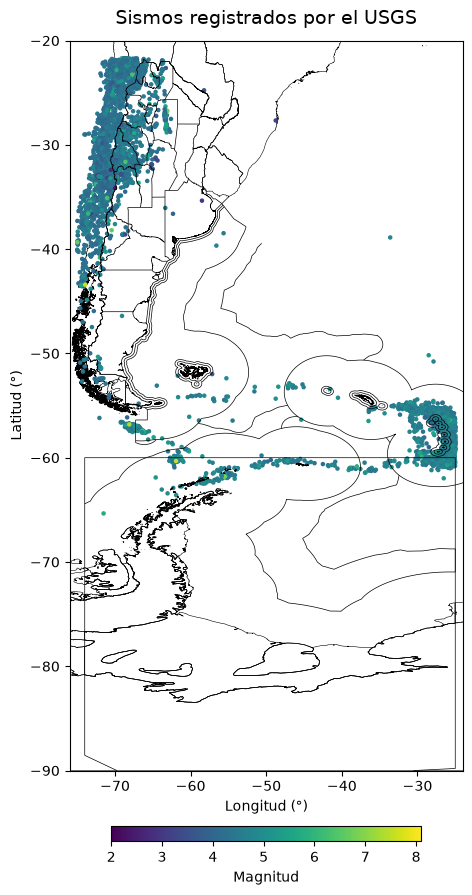

In [72]:

fig, ax = plt.subplots(figsize=(10, 12))

ign_sudam.plot(
    ax=ax,
    facecolor="none",
    edgecolor="black",
    linewidth=0.4
)

ign_arg.plot(
    ax=ax,
    color="black",
    linewidth=0.5
)

gdf.plot(
    ax=ax,
    column="mag",
    cmap="viridis",
    markersize=5,
    legend=True,
    legend_kwds={"label": "Magnitud",
        "orientation": "horizontal",
        "shrink": 0.4,
        "pad": 0.06
    }
)

# Zoom sobre Argentina y alrededores
ax.set_xlim(-76, -24)
ax.set_ylim(-90, -20)


ax.set_xlabel("Longitud (°)")
ax.set_ylabel("Latitud (°)")
ax.set_title(
    "Sismos registrados por el USGS",
    fontsize=14,
    pad=12
)

plt.show()

**Figura 1. Eventos sísmicos registrados por el USGS dentro del área rectangular inicial de consulta.**

 El mapa incluye zonas externas a Argentina, ya que la API se consultó utilizando un rectángulo geográfico amplio. Estos eventos serán filtrados posteriormente mediante un polígono más preciso del territorio argentino.

# 3. Definición del área de estudio

Para quedarse solo con los sismos de Argentina se arma un polígono que une tres zonas:

- las provincias argentinas (capa del IGN),
- la plataforma continental argentina (capa del IGN), para incluir los sismos en el mar, y
- el sector antártico argentino, entre los meridianos 25° O y 74° O, al sur del paralelo 60° S.

Se conservan los eventos cuyos epicentros se encuentran dentro de ese polígono. El resultado se guarda en `df_arg`, que es el conjunto que se analiza en el resto del notebook.

In [ ]:
# Lectura de archivos SHP: provincias y plataforma continental (IGN)

ign_provincias = gpd.read_file("../data/raw/geodata/provinciaPolygon.shp")
ign_plataforma = gpd.read_file("../data/raw/geodata/plataforma_continentalPolygon.shp")


# Armado del sector antártico argentino

coordenadas_antartida = [
    (-74.0, -60.0),  # Esquina Noroeste
    (-25.0, -60.0),  # Esquina Noreste
    (-25.0, -90.0),  # Polo Sur (Límite Este)
    (-74.0, -90.0),  # Polo Sur (Límite Oeste)
    (-74.0, -60.0)   # Cierre
]

poligono_antartico = Polygon(coordenadas_antartida)

# Unión de las 3 geometrías en un solo polígono

poligono_nacional = (
    ign_provincias.union_all()
    .union(ign_plataforma.union_all())
    .union(poligono_antartico)
)



In [ ]:
# Filtrado de puntos ubicados dentro del polígono

gdf_arg = gdf[gdf.geometry.within(poligono_nacional)]

df_arg = pd.DataFrame(gdf_arg.drop(columns='geometry'))


Visualización de los sismos en Argentina entre 2016 y 2026

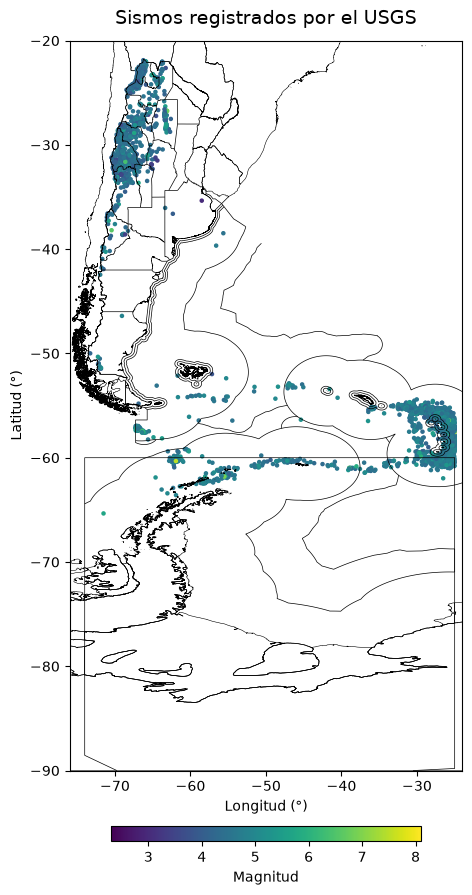

In [74]:
fig, ax = plt.subplots(figsize=(10, 12))

ign_sudam.plot(
    ax=ax,
    facecolor="none",
    edgecolor="black",
    linewidth=0.4
)

ign_arg.plot(
    ax=ax,
    color="black",
    linewidth=0.5
)

gdf_arg.plot(
    ax=ax,
    column="mag",
    cmap="viridis",
    markersize=5,
    legend=True,
    legend_kwds={"label": "Magnitud",
        "orientation": "horizontal",
        "shrink": 0.4,
        "pad": 0.06
    }
)

# Zoom sobre Argentina y alrededores
ax.set_xlim(-76, -24)
ax.set_ylim(-90, -20)


ax.set_xlabel("Longitud (°)")
ax.set_ylabel("Latitud (°)")
ax.set_title(
    "Sismos registrados por el USGS",
    fontsize=14,
    pad=12
)

plt.show()

**Figura 2. Eventos sísmicos registrados por el USGS dentro del área de estudio.**


# 4. Exploración inicial del conjunto de datos


Se analiza la estructura general de los datos: cuántas filas y columnas hay, de qué tipo es cada variable, cuántos valores faltan y si hay registros duplicados.

### 4.1 Estructura y tipos de datos

In [13]:
print("Filas:", df_arg.shape[0])
print("Columnas:", df_arg.shape[1])


Filas: 6431
Columnas: 22


In [14]:
df_arg.head(3)

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,net,id,updated,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource
0,2026-09-14T05:03:12.877Z,-24.1313,-66.9986,189.041,4.4,mb,35.0,77.0,2.572,0.66,us,us7000than,2026-09-14T06:21:54.040Z,"69 km W of San Antonio de los Cobres, Argentina",earthquake,3.33,13.010,0.149,13.0,reviewed,us,us
1,2026-09-13T19:40:25.496Z,-26.1509,-66.6119,10.000,4.7,mb,46.0,54.0,2.863,0.78,us,us7000th7y,2026-09-24T17:19:43.040Z,"64 km W of Cafayate, Argentina",earthquake,6.25,1.889,0.088,39.0,reviewed,us,us
3,2026-09-12T11:05:46.433Z,-56.2951,-26.9013,102.352,4.9,mb,30.0,67.0,5.836,0.79,us,us7000tgyw,2026-09-23T07:20:17.040Z,South Sandwich Islands region,earthquake,12.33,7.797,0.106,28.0,reviewed,us,us


In [15]:
df_arg.describe().round(3)

,latitude,longitude,depth,mag,nst,gap,dmin,rms,horizontalError,depthError,magError,magNst
count,6431.000,6431.000,6431.000,6431.000,2558.000,6423.000,6423.000,6429.000,6429.000,6431.000,6204.000,6202.000
mean,-45.514,-45.239,90.116,4.589,42.124,86.649,5.387,0.752,9.495,5.428,0.136,28.407
std,15.800,19.740,94.030,0.395,35.240,40.167,4.689,0.234,3.027,3.862,0.069,36.063
min,-65.344,-73.275,1.000,2.300,7.000,12.000,0.041,0.090,1.500,0.600,0.022,1.000
25%,-58.759,-66.935,10.000,4.300,21.000,58.000,1.615,0.590,7.300,1.900,0.089,11.000
50%,-55.850,-30.820,43.260,4.500,30.000,79.000,4.844,0.730,9.420,4.900,0.123,18.000
75%,-24.925,-26.055,167.576,4.800,51.000,107.500,7.457,0.900,11.570,7.800,0.164,33.000
max,-21.880,-25.002,626.010,8.100,466.000,292.000,32.456,2.480,28.300,32.700,0.539,663.000


In [16]:
df_arg.info()

<class 'pandas.DataFrame'>
Index: 6431 entries, 0 to 10794
Data columns (total 22 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   time             6431 non-null   str    
 1   latitude         6431 non-null   float64
 2   longitude        6431 non-null   float64
 3   depth            6431 non-null   float64
 4   mag              6431 non-null   float64
 5   magType          6431 non-null   str    
 6   nst              2558 non-null   float64
 7   gap              6423 non-null   float64
 8   dmin             6423 non-null   float64
 9   rms              6429 non-null   float64
 10  net              6431 non-null   str    
 11  id               6431 non-null   str    
 12  updated          6431 non-null   str    
 13  place            6431 non-null   str    
 14  type             6431 non-null   str    
 15  horizontalError  6429 non-null   float64
 16  depthError       6431 non-null   float64
 17  magError         6204 non-nul

### 4.2 Valores faltantes

In [17]:
nulos = df_arg.isna().sum()
nulos[nulos>0]

nst                3873
gap                   8
dmin                  8
rms                   2
horizontalError       2
magError            227
magNst              229
dtype: int64

In [18]:
# Análisis porcentual de nulos

((nulos[nulos>0]/df_arg.shape[0])*100).round(3)

nst                60.224
gap                 0.124
dmin                0.124
rms                 0.031
horizontalError     0.031
magError            3.530
magNst              3.561
dtype: float64

Nst presenta aproximadamente un 60 % de valores faltantes, por lo que se propone excluirla del análisis posterior. Para las restantes variables, los faltantes representan una proporción reducida y se propone imputarlos mediante la mediana durante la etapa de transformación.

### 4.3 Registros duplicados


In [19]:
id = df_arg["id"].value_counts()
id[id>1]

Series([], Name: count, dtype: int64)

In [20]:
df_arg.duplicated().value_counts()

False    6431
Name: count, dtype: int64

No existen filas ni identificadores duplicados.

### 4.4 Variables categóricas


#### 4.4.1 Última actualización del evento

In [21]:
df_arg["updated"].value_counts()

updated
2024-08-16T21:59:24.040Z    18
2026-01-01T23:11:08.040Z    11
2025-07-12T16:30:42.040Z    11
2021-10-29T14:47:05.040Z    11
2021-10-29T14:46:49.040Z    11
                            ..
2016-12-12T23:01:28.040Z     1
2025-12-22T17:17:54.106Z     1
2016-12-12T23:01:27.040Z     1
2016-12-12T23:01:26.040Z     1
2025-12-22T17:17:51.214Z     1
Name: count, Length: 4764, dtype: int64

#### 4.4.2 Fecha y hora exacta del evento

In [22]:
df_arg["time"].value_counts()

time
2026-09-14T05:03:12.877Z    1
2026-09-13T19:40:25.496Z    1
2026-09-12T11:05:46.433Z    1
2026-09-09T10:06:57.170Z    1
2026-09-08T06:50:46.470Z    1
                           ..
2016-09-17T01:02:21.620Z    1
2016-09-16T12:04:39.700Z    1
2016-09-15T04:50:34.110Z    1
2016-09-15T02:37:59.150Z    1
2016-09-15T01:06:30.870Z    1
Name: count, Length: 6431, dtype: int64

Las columnas “updated” y “time” se transformarán a tipo DateTime en la etapa de transformación.

#### 4.4.3 Tipo de medición de magnitud

In [23]:

df_arg["magType"].value_counts()

magType
mb       5650
mww       458
mwr       267
ml         45
md          6
mw          2
mb_lg       2
mwb         1
Name: count, dtype: int64

No presenta categorías o valores que requieran un tratamiento particular.

#### 4.4.4 Estado de revisión

In [24]:
df_arg["status"].value_counts()

status
reviewed    6431
Name: count, dtype: int64

#### 4.4.5 Tipo de evento

In [25]:
df_arg["type"].value_counts()

type
earthquake    6431
Name: count, dtype: int64

#### 4.4.6 Red sísmica de preferencia para el evento

In [26]:
df_arg["net"].value_counts()

net
us        6429
iscgem       2
Name: count, dtype: int64

#### 4.4.7 Red sísmica que localizó el evento

In [27]:
df_arg["locationSource"].value_counts()

locationSource
us        6423
sja          4
iscgem       2
guc          2
Name: count, dtype: int64

#### 4.4.8 Red sísmica que calculó la magnitud

In [28]:
df_arg["magSource"].value_counts()

magSource
us        6207
guc        216
sja          6
iscgem       2
Name: count, dtype: int64

Las variables categóricas con una categoría ampliamente predominante presentan poca variabilidad dentro del conjunto de datos y tienen una utilidad limitada para los análisis planteados. Por este motivo, se propone no considerarlas en el análisis posterior.

# 5. Análisis de magnitud y error de magnitud

La magnitud (`mag`) es una de las variables centrales del proyecto: mide la energía liberada por cada sismo y es la base para definir qué se considera actividad sísmica significativa en el modelo supervisado.

En esta sección se analiza:

- **La distribución de la magnitud**, para conocer el rango de valores y detectar registros atípicos.
- **El error de magnitud** (`magError`), para identificar mediciones con una incertidumbre desproporcionada que pudieran no ser confiables.

### 5.1 Distribución de la magnitud


In [29]:
df_arg['mag'].value_counts().sort_index()

mag
2.30      1
3.00      2
3.30      5
3.40      6
3.50      1
3.60      1
3.70      4
3.80     13
3.90     25
4.00    177
4.10    262
4.20    523
4.30    729
4.40    816
4.50    913
4.60    771
4.70    503
4.80    270
4.90    394
5.00    309
5.06      1
5.10    212
5.18      1
5.20    138
5.30     90
5.40     58
5.50     46
5.60     47
5.70     35
5.80     10
5.90     11
6.00     13
6.10     10
6.20      6
6.30      4
6.40     10
6.50      3
6.60      3
6.70      1
6.80      2
6.90      1
7.50      2
7.60      1
8.10      1
Name: count, dtype: int64

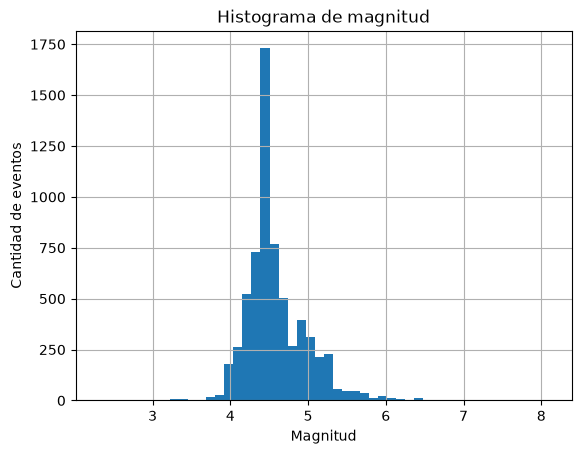

In [76]:
ax = df_arg["mag"].hist(bins=50)

ax.set_title("Histograma de magnitud")
ax.set_xlabel("Magnitud")
ax.set_ylabel("Cantidad de eventos")

plt.show()

**Figura 3. Distribución de la magnitud de los sismos del área de análisis.**

El histograma muestra la cantidad de eventos registrados en cada intervalo de magnitud.

Análisis de variables atípicas:

In [31]:
index1 = df_arg[df_arg['mag']==5.06].index
index2 = df_arg[df_arg['mag']==5.18].index

In [32]:
df_arg[df_arg["mag"].isin([5.06, 5.18])]

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,net,id,updated,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource
4848,2021-12-04T04:32:02.340Z,-59.762,-29.666,10.0,5.06,mw,NaN,NaN,NaN,NaN,iscgem,iscgem621613005,2025-12-22T22:21:35.177Z,South Sandwich Islands region,earthquake,NaN,25.0,0.1,NaN,reviewed,iscgem,iscgem
6306,2021-03-14T14:09:13.950Z,-59.303,-31.041,10.0,5.18,mw,NaN,NaN,NaN,NaN,iscgem,iscgem620210242,2025-12-22T18:55:19.233Z,Scotia Sea,earthquake,NaN,25.0,0.1,NaN,reviewed,iscgem,iscgem


Se identificaron dos registros con valores de magnitud que resultan atípicos respecto del resto del conjunto de datos. Ambos presentan valores faltantes simultáneamente en nst, gap, dmin, rms, horizontalError y magNst, siendo estas variables de calidad. Al no poder evaluar la confiabilidad de las mediciones se recomienda excluir ambos registros del análisis posterior.

### 5.2 Error de magnitud


In [34]:
bins = [0, 1, 2, 3, 4, 4.5, 5, 6, 7, 8, 9, 10]

mag_groups = pd.cut(
    df_arg['mag'],
    bins=bins,
    include_lowest=True
)


mag_error_summary = (
    df_arg
    .groupby(mag_groups, observed=True)['magError']
    .agg(
        count='count',
        median='median',
        q3=lambda x: x.quantile(0.75),
        max='max'
    )
)


mag_error_summary

,count,median,q3,max
mag,,,,
"(2.0, 3.0]",3,0.058,0.1765,0.295
"(3.0, 4.0]",215,0.232,0.2970,0.520
"(4.0, 4.5]",3093,0.154,0.1970,0.539
"(4.5, 5.0]",2191,0.102,0.1230,0.385
"(5.0, 6.0]",659,0.069,0.0830,0.152
"(6.0, 7.0]",39,0.048,0.0590,0.105
"(7.0, 8.0]",3,0.041,0.0520,0.063
"(8.0, 9.0]",1,0.065,0.0650,0.065


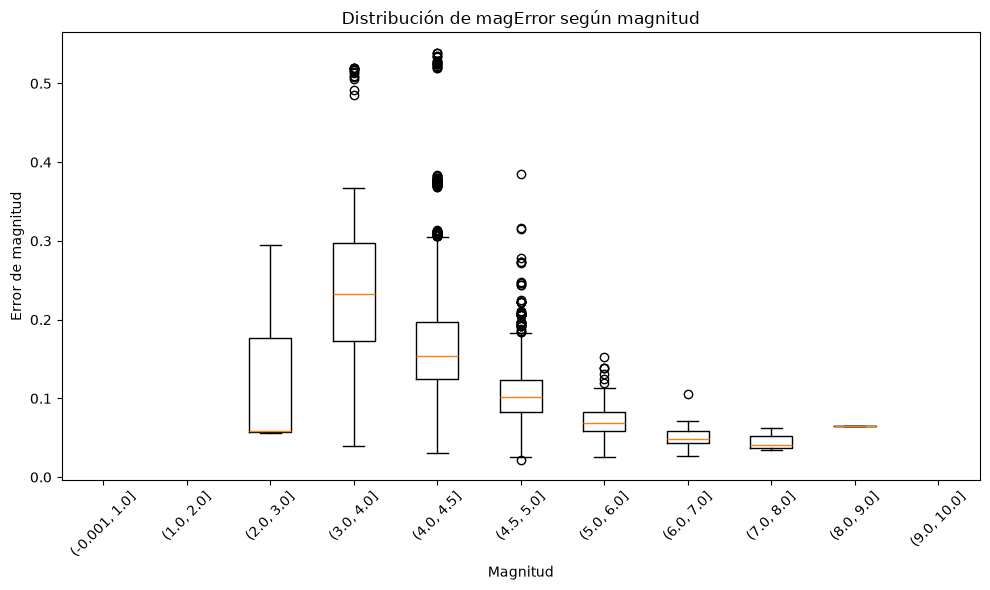

In [35]:
data_boxplot = [
    df_arg.loc[mag_groups == grupo, 'magError'].dropna()
    for grupo in mag_groups.cat.categories
]

labels = [
    str(grupo)
    for grupo in mag_groups.cat.categories
]

plt.figure(figsize=(10, 6))

plt.boxplot(
    data_boxplot,
    tick_labels=labels
)

plt.xlabel('Magnitud')
plt.ylabel('Error de magnitud')
plt.title('Distribución de magError según magnitud')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Figura 4. Distribución del error de magnitud según el grupo de magnitud.**

Cada caja resume los valores de `magError` observados dentro de un intervalo de magnitud. La comparación permite evaluar si la incertidumbre de la medición varía entre eventos de distinta magnitud.

In [36]:

df_arg[(df_arg["magError"]>=0.4) & (df_arg["mag"]>4) & (df_arg["mag"]<=4.5)]

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,net,id,updated,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource
714,2025-11-24T14:18:18.405Z,-30.9301,-69.0523,115.172,4.1,mb,23.0,127.0,0.695,0.57,us,us6000rq39,2026-02-20T16:07:36.040Z,"56 km NE of Calingasta, Argentina",earthquake,4.97,6.054,0.520,1.0,reviewed,us,us
1567,2025-02-18T19:49:19.657Z,-24.2802,-67.1293,196.298,4.2,mb,27.0,136.0,1.636,0.55,us,us7000pekv,2025-05-02T16:26:22.040Z,"82 km W of San Antonio de los Cobres, Argentina",earthquake,7.97,11.314,0.529,1.0,reviewed,us,us
3846,2022-09-25T17:02:28.568Z,-23.3799,-66.8356,222.538,4.4,mb,18.0,101.0,1.307,0.22,us,us7000iays,2022-12-03T22:03:23.040Z,"106 km NNW of San Antonio de los Cobres, Argen...",earthquake,6.78,14.065,0.538,3.0,reviewed,us,us
4177,2022-06-01T19:42:37.746Z,-28.1369,-67.0873,161.740,4.4,mb,28.0,136.0,2.838,0.55,us,us7000he6b,2022-08-06T22:13:14.040Z,"47 km S of Londres, Argentina",earthquake,10.70,5.200,0.535,1.0,reviewed,us,us
6506,2021-01-08T12:54:17.688Z,-26.5272,-65.7243,10.000,4.1,mb,NaN,108.0,4.215,0.87,us,us6000d6qr,2021-03-20T21:22:50.040Z,"36 km N of Tafí del Valle, Argentina",earthquake,8.80,1.900,0.521,1.0,reviewed,us,us
6864,2020-10-01T16:50:02.581Z,-24.1584,-66.8462,184.880,4.1,mb,NaN,112.0,1.713,1.26,us,us6000c416,2020-12-12T22:28:30.040Z,"53 km W of San Antonio de los Cobres, Argentina",earthquake,8.10,6.800,0.520,2.0,reviewed,us,us
7051,2020-08-14T12:31:47.447Z,-22.6196,-66.3129,259.250,4.1,mb,NaN,134.0,1.753,0.48,us,us6000bhna,2020-10-24T20:09:06.040Z,"64 km W of Abra Pampa, Argentina",earthquake,13.10,9.600,0.521,1.0,reviewed,us,us
7367,2020-04-14T16:49:18.091Z,-23.1204,-66.8896,241.190,4.1,mb,NaN,175.0,1.199,0.47,us,us70008w46,2020-06-30T14:03:10.040Z,"124 km W of El Aguilar, Argentina",earthquake,15.30,9.200,0.522,1.0,reviewed,us,us
7435,2020-03-24T21:13:03.645Z,-23.3583,-67.0925,213.920,4.2,mb,NaN,78.0,1.078,0.74,us,us70008fcu,2020-06-06T20:54:16.040Z,"123 km NW of San Antonio de los Cobres, Argentina",earthquake,5.60,13.700,0.526,1.0,reviewed,us,us
9411,2017-11-19T14:27:10.300Z,-24.0257,-67.3054,198.830,4.4,mb,NaN,128.0,1.336,0.45,us,us2000brfz,2018-02-14T02:01:03.040Z,"102 km WNW of San Antonio de los Cobres, Argen...",earthquake,8.50,19.600,0.535,1.0,reviewed,us,us


In [37]:
pd.set_option('display.max_columns', None)

df_arg[(df_arg["magError"]>=0.37) & (df_arg["mag"]>4.5) & (df_arg["mag"]<=5)]

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,net,id,updated,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource
7458,2020-03-10T13:07:32.821Z,-28.5433,-68.803,130.4,4.6,mb,NaN,79.0,1.324,0.55,us,us60008d4l,2020-05-23T22:03:16.040Z,"63 km WNW of Vinchina, Argentina",earthquake,8.5,8.4,0.385,2.0,reviewed,us,us


No se identifican criterios suficientes para descartar los datos.

# 6. Análisis de profundidad y error de profundidad

La profundidad (`depth`) indica a cuántos kilómetros bajo la superficie se originó cada sismo. En Argentina es especialmente relevante: la placa de Nazca se hunde bajo la placa Sudamericana, por lo que se observan sismos de distintas profundidades a lo largo de la zona de subducción, con sismos superficiales cerca de la cordillera y sismos más profundos hacia el interior del continente.

En esta sección se analiza:

- **La distribución de la profundidad**, en general y en el espacio (gráfico 3D), para verificar que los valores tengan sentido físico.
- **El error de profundidad** (`depthError`), para identificar mediciones poco precisas.
- **Los registros con varios valores faltantes a la vez**, que aparecieron repetidamente durante el análisis y requieren una decisión.

### 6.1 Distribución de la profundidad


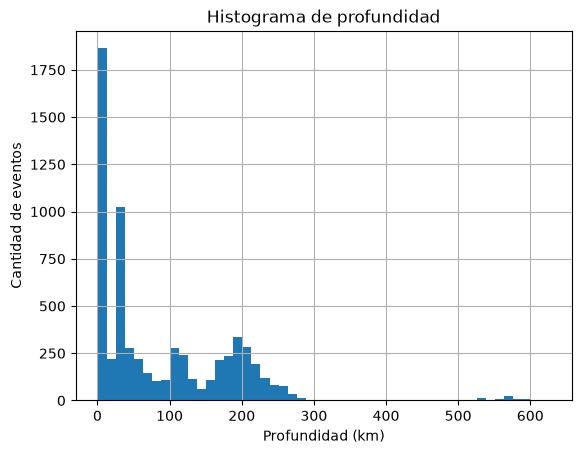

In [77]:
ax = df_arg["depth"].hist(bins=50)

ax.set_title("Histograma de profundidad")
ax.set_xlabel("Profundidad (km)")
ax.set_ylabel("Cantidad de eventos")

plt.show()

**Figura 5. Distribución de la profundidad de los sismos del área de análisis.**

El histograma muestra la cantidad de eventos registrados en cada intervalo de profundidad, expresada en kilómetros.

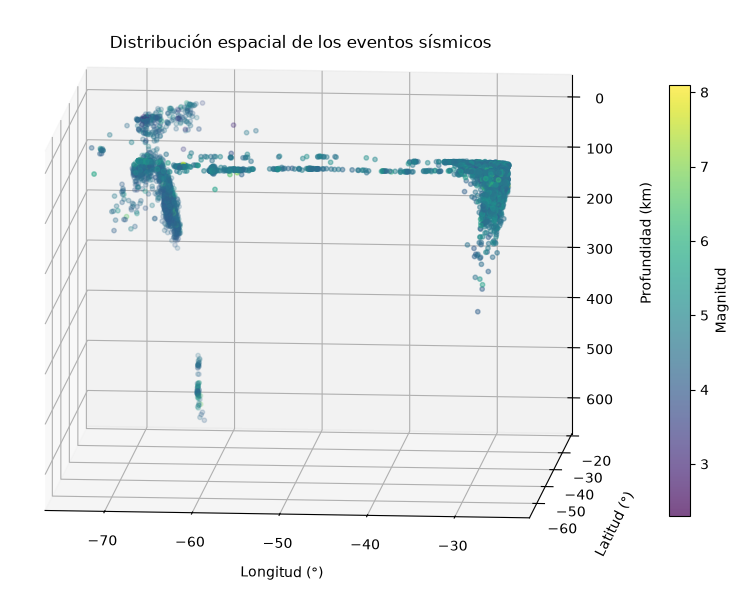

In [96]:
fig = plt.figure(figsize=(10, 8))

ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    df_arg['longitude'],
    df_arg['latitude'],
    df_arg['depth'],
    c=df_arg['mag'],
    cmap='viridis',
    s=10,
    alpha=0.7
)

ax.set_xlabel('Longitud (°)', labelpad=8)
ax.set_ylabel('Latitud (°)', labelpad=8)
ax.set_zlabel('Profundidad (km)', labelpad=10)

ax.invert_zaxis()

ax.view_init(elev=10, azim=-85)

# Perspectiva de los ticks
ax.set_proj_type('ortho')

ax.set_box_aspect(None, zoom=1.3)

ax.set_title(
    'Distribución espacial de los eventos sísmicos',
    y=1
)

fig.colorbar(
    scatter,
    ax=ax,
    label='Magnitud',
    shrink=0.7,
    pad=0.1
)

plt.show()

**Figura 6. Relación entre profundidad y magnitud de los eventos.**

La representación tridimensional permite observar la profundidad de cada evento y su magnitud mediante la escala de color, facilitando la identificación de variaciones en ambas características.

Los eventos con profundidades superiores a 500 km se conservarán en el conjunto de datos, ya que su profundidad no constituye por sí misma un criterio suficiente para considerarlos registros anómalos.

### 6.2 Error de profundidad


In [40]:
bins = [0, 10, 20, 40, 65, 100, 200, 300, 400, 500, 600, 650]

depth_groups = pd.cut(
    df_arg['depth'],
    bins=bins,
    include_lowest=True
)


depth_error_summary = (
    df_arg
    .groupby(depth_groups, observed=True)['depthError']
    .agg(
        count='count',
        median='median',
        q3=lambda x: x.quantile(0.75),
        max='max'
    )
)


depth_error_summary

,count,median,q3,max
depth,,,,
"(-0.001, 10.0]",1806,1.900,1.90000,25.000
"(10.0, 20.0]",164,4.400,5.20000,8.005
"(20.0, 40.0]",1178,2.000,5.10000,21.700
"(40.0, 65.0]",480,6.900,8.50000,16.002
"(65.0, 100.0]",321,6.796,8.10000,19.210
"(100.0, 200.0]",1580,7.200,9.11525,25.700
"(200.0, 300.0]",829,9.500,12.32900,32.700
"(300.0, 400.0]",1,10.300,10.30000,10.300
"(500.0, 600.0]",68,6.841,8.24450,18.600


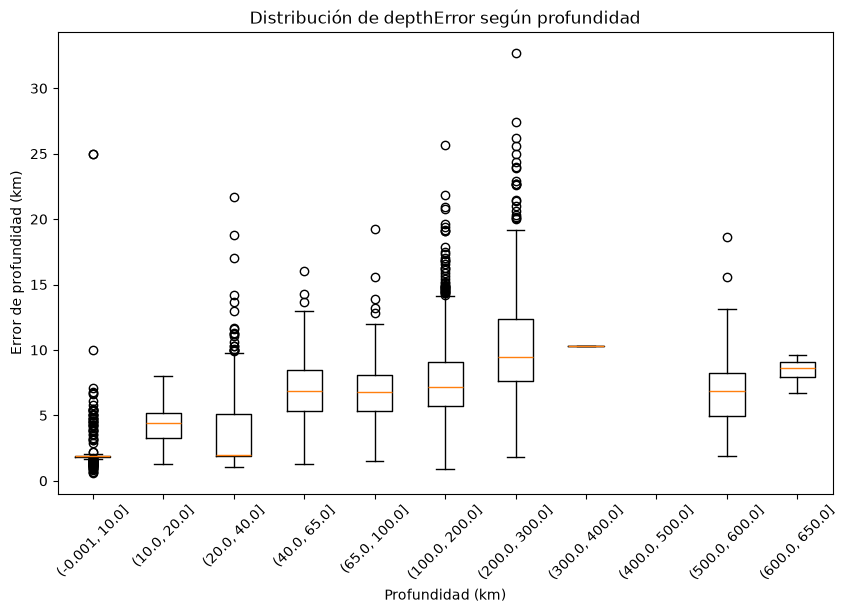

In [ ]:
data_boxplot = [
    df_arg.loc[depth_groups == grupo, 'depthError'].dropna()
    for grupo in depth_groups.cat.categories
]

labels = [
    str(grupo)
    for grupo in depth_groups.cat.categories
]

plt.figure(figsize=(10, 6))

plt.boxplot(
    data_boxplot,
    tick_labels=labels
)

plt.xlabel('Profundidad (km)')
plt.ylabel('Error de profundidad (km)')
plt.title('Distribución de depthError según profundidad')

plt.xticks(rotation=45)

plt.show()

**Figura 7. Error de profundidad según rangos de profundidad.**

El diagrama de cajas permite comparar la distribución del error de profundidad entre los distintos intervalos, mostrando su mediana, dispersión y posibles valores extremos.


Observación de valores extremos:

In [42]:

df_arg[(df_arg["depthError"]==25) & (df_arg["depth"]<11)]

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,net,id,updated,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource
4848,2021-12-04T04:32:02.340Z,-59.762,-29.666,10.0,5.06,mw,NaN,NaN,NaN,NaN,iscgem,iscgem621613005,2025-12-22T22:21:35.177Z,South Sandwich Islands region,earthquake,NaN,25.0,0.1,NaN,reviewed,iscgem,iscgem
6306,2021-03-14T14:09:13.950Z,-59.303,-31.041,10.0,5.18,mw,NaN,NaN,NaN,NaN,iscgem,iscgem620210242,2025-12-22T18:55:19.233Z,Scotia Sea,earthquake,NaN,25.0,0.1,NaN,reviewed,iscgem,iscgem


In [43]:

df_arg[(df_arg["depthError"]>=15) & (df_arg["depth"]>20) & (df_arg["depth"]<41)]

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,net,id,updated,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource
5260,2021-09-05T18:38:59.897Z,-59.7193,-26.4103,36.14,4.4,mb,NaN,201.0,7.737,1.22,us,us7000fate,2021-11-17T17:23:34.040Z,South Sandwich Islands region,earthquake,20.2,18.8,0.139,15.0,reviewed,us,us
8001,2019-07-15T09:06:19.255Z,-25.4759,-64.4012,37.00,4.3,mb,NaN,45.0,4.266,1.16,us,us70004kgk,2019-09-28T20:01:25.040Z,"27 km ESE of El Galpón, Argentina",earthquake,7.7,17.0,0.308,4.0,reviewed,us,us
9869,2017-05-25T12:10:58.310Z,-30.1939,-67.2047,36.77,4.5,mb,NaN,66.0,1.853,1.29,us,us10008v9q,2017-08-10T01:34:01.040Z,"54 km NNE of San Agustín de Valle Fértil, Arge...",earthquake,6.7,21.7,0.312,3.0,reviewed,us,us


In [44]:

df_arg[(df_arg["depthError"]==25.700) & (df_arg["depth"]>100) & (df_arg["depth"]<201)]

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,net,id,updated,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource
7955,2019-08-11T15:02:40.811Z,-28.2586,-67.569,167.69,4.1,ml,NaN,187.0,1.982,0.13,us,us600053qt,2019-10-29T20:33:59.040Z,"21 km S of Tinogasta, Argentina",earthquake,11.8,25.7,0.064,32.0,reviewed,us,us


In [45]:
df_arg[(df_arg["depthError"]==32.700) & (df_arg["depth"]<301)]

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,net,id,updated,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource
9893,2017-05-16T18:05:30.780Z,-23.9779,-66.9937,243.36,4.1,ml,NaN,222.0,2.225,0.97,us,us10008ssu,2017-08-05T03:32:09.040Z,"73 km WNW of San Antonio de los Cobres, Argentina",earthquake,10.3,32.7,NaN,NaN,reviewed,us,guc


No se identifican criterios suficientes para descartar los datos.

### 6.3 Análisis de registros con múltiples valores faltantes


Se analiza por la reiterada presencia de datos con varias columnas NaN.


In [46]:

df_nan = df_arg.isna().sum(axis=1)

df_arg.loc[
    df_nan > 2, ["depth","depthError","mag","magError", "magNst","gap","dmin","rms","nst","horizontalError" ]
].assign(
    nan_count=df_nan
).sort_values(
    by='nan_count',
    ascending=False
)

,depth,depthError,mag,magError,magNst,gap,dmin,rms,nst,horizontalError,nan_count
4848,10.00,25.0,5.06,0.100,NaN,NaN,NaN,NaN,NaN,NaN,6
6306,10.00,25.0,5.18,0.100,NaN,NaN,NaN,NaN,NaN,NaN,6
10522,223.00,6.0,5.00,NaN,NaN,NaN,NaN,1.88,NaN,7.1,5
10628,33.00,10.1,3.30,NaN,NaN,NaN,NaN,0.59,NaN,11.2,5
4623,118.79,3.8,4.70,NaN,NaN,42.0,0.884,0.91,NaN,5.6,3
...,...,...,...,...,...,...,...,...,...,...,...
10568,250.41,12.7,4.00,NaN,NaN,233.0,1.510,0.71,NaN,8.1,3
10612,208.74,7.6,4.60,NaN,NaN,41.0,1.764,0.75,NaN,8.0,3
10615,148.98,6.7,4.70,NaN,NaN,28.0,2.437,0.79,NaN,7.7,3
10681,10.00,4.6,5.00,0.133,18.0,NaN,NaN,0.83,NaN,7.4,3


In [ ]:
# Id de los registros con 5 o más valores NaN

nan_count = df_arg.isna().sum(axis=1)

registros_incompletos = df_arg[nan_count >= 5]

registros_incompletos["id"].tolist()

['iscgem621613005', 'iscgem620210242', 'us10007f0t', 'us100073ln']

Los registros que presentan 5 o 6 variables NaN quedan prácticamente sin variables de métrica de calidad, por lo que propongo descartarlos (notar que las primeras dos ya se había propuesto descartarlas). El resto tiene 3 métricas faltantes, como no todas tienen el mismo peso, veo que patrones existen:

In [48]:
df_arg.loc[
    df_nan == 3,
    ['nst', 'gap', 'dmin', 'rms', 'horizontalError', 'depthError', 'magError', 'magNst']
].isna().astype(int).value_counts()


nst  gap  dmin  rms  horizontalError  depthError  magError  magNst
1    0    0     0    0                0           1         1         146
     1    1     0    0                0           0         0           4
Name: count, dtype: int64

En un principio, según estos resultados, podrían mantenerse todas las filas con 3 variables NaN.

# 7. Análisis de variables de calidad

Se revisan las variables que indican qué tan confiable es cada medición. Para cada una se muestra un resumen estadístico, un boxplot para ver los valores extremos y el detalle de los registros más altos, para decidir si son errores o datos válidos.


### 7.1 Error horizontal


In [49]:
df_arg["horizontalError"].describe()

count    6429.000000
mean        9.494914
std         3.027041
min         1.500000
25%         7.300000
50%         9.420000
75%        11.570000
max        28.300000
Name: horizontalError, dtype: float64

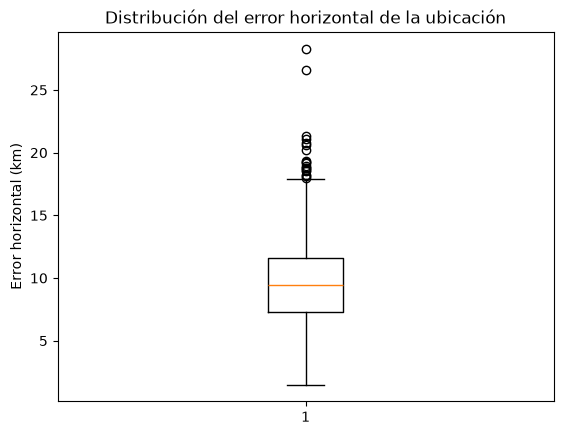

In [50]:
plt.boxplot(df_arg["horizontalError"].dropna())
plt.ylabel("Error horizontal (km)")
plt.title("Distribución del error horizontal de la ubicación")
plt.show()

**Figura 8. Precisión de la ubicación de los eventos sísmicos.**

El diagrama de cajas permite observar la dispersión del error horizontal asociado a la ubicación de los eventos y la presencia de posibles valores extremos.

In [51]:

df_arg[(df_arg["horizontalError"]>=25)]

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,net,id,updated,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource
742,2025-11-13T02:44:20.935Z,-58.9814,-25.7406,87.293,4.4,mb,14.0,234.0,7.565,1.11,us,us7000rf2m,2026-02-10T15:55:17.040Z,South Sandwich Islands region,earthquake,26.59,19.21,0.143,14.0,reviewed,us,us
8445,2019-01-04T19:45:03.470Z,-60.6901,-26.5353,10.000,4.7,mb,NaN,164.0,14.442,1.03,us,us2000j7be,2019-03-08T17:50:21.040Z,South Sandwich Islands region,earthquake,28.30,1.90,0.152,14.0,reviewed,us,us


### 7.2 Gap


In [52]:
df_arg["gap"].describe()

count    6423.000000
mean       86.649229
std        40.167414
min        12.000000
25%        58.000000
50%        79.000000
75%       107.500000
max       292.000000
Name: gap, dtype: float64

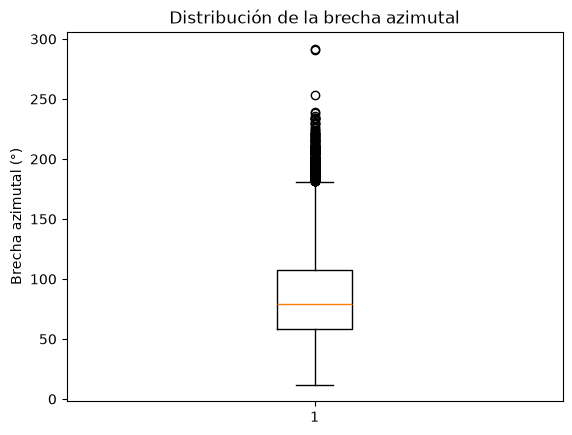

In [83]:
plt.boxplot(df_arg["gap"].dropna())
plt.ylabel("Brecha azimutal (°)")
plt.title("Distribución de la brecha azimutal")
plt.show()

**Figura 9. Cobertura azimutal de las estaciones sísmicas.**

El gráfico muestra la distribución de la brecha azimutal (gap), una medida de la cobertura de estaciones sísmicas alrededor del epicentro. Valores elevados indican una distribución menos favorable de las estaciones y, por lo tanto, una posible menor confiabilidad en la localización. Los valores extremos se revisan posteriormente para identificar los registros que requieren atención.

In [54]:
df_arg[(df_arg["gap"]>=290)]

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,net,id,updated,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource
340,2026-05-06T01:19:20.881Z,-31.8481,-65.1886,10.0,3.3,ml,14.0,292.0,2.983,0.66,us,us6000svif,2026-07-15T15:25:55.040Z,"10 km N of Villa Dolores, Argentina",earthquake,6.03,2.027,0.081,20.0,reviewed,us,us
7244,2020-05-30T13:17:23.330Z,-60.8367,-26.3896,10.0,4.6,mb,NaN,291.0,8.513,0.54,us,us6000a6gy,2020-08-15T20:19:53.040Z,South Sandwich Islands region,earthquake,9.80,2.000,0.132,17.0,reviewed,us,us


### 7.3 Distancia mínima


In [55]:
df_arg["dmin"].describe()

count    6423.000000
mean        5.386548
std         4.688509
min         0.041000
25%         1.615000
50%         4.844000
75%         7.457000
max        32.456000
Name: dmin, dtype: float64

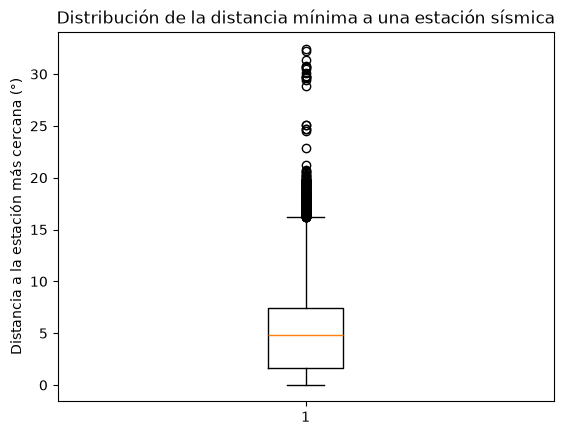

In [56]:
plt.boxplot(df_arg["dmin"].dropna())
plt.ylabel("Distancia a la estación más cercana (°)")
plt.title("Distribución de la distancia mínima a una estación sísmica")
plt.show()

**Figura 10. Cercanía de los eventos a las estaciones sísmicas.**

El gráfico muestra la distribución de dmin, que representa la distancia angular entre cada epicentro y la estación sísmica más cercana. Valores bajos indican una estación próxima al evento, mientras que valores altos reflejan una menor proximidad de estaciones y pueden asociarse con una localización menos precisa. La variable se interpreta como un indicador de calidad, no como una característica física del sismo.

### 7.4 RMS


In [57]:
df_arg["rms"].describe()

count    6429.000000
mean        0.751946
std         0.234355
min         0.090000
25%         0.590000
50%         0.730000
75%         0.900000
max         2.480000
Name: rms, dtype: float64

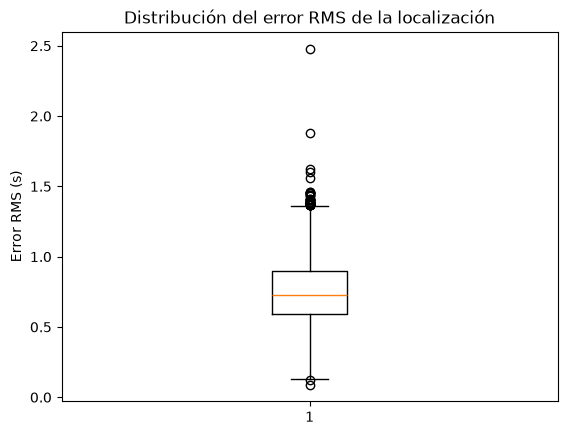

In [58]:
plt.boxplot(df_arg["rms"].dropna())
plt.ylabel("Error RMS (s)")
plt.title("Distribución del error RMS de la localización")
plt.show()

**Figura 11. Calidad del ajuste de la localización de los eventos.**

El gráfico representa la distribución del error RMS asociado a la localización de los sismos. Este indicador mide el ajuste entre los tiempos de llegada observados y los tiempos estimados por el modelo. Valores bajos sugieren una mayor concordancia, mientras que los valores altos pueden señalar registros cuya localización presenta mayor incertidumbre. Los valores extremos se revisan individualmente en el bloque siguiente.

In [59]:
df_arg[(df_arg["rms"]>=2)]

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,net,id,updated,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource
8430,2019-01-09T17:55:27.940Z,-38.5913,-68.6584,1.0,3.4,mb_lg,NaN,221.0,2.403,2.48,us,us2000j8kv,2022-08-08T13:49:38.005Z,"28 km SSE of Añelo, Argentina",earthquake,8.9,10.0,0.085,36.0,reviewed,us,us


### 7.5 Nst de magnitud

In [60]:
df_arg["magNst"].describe()

count    6202.000000
mean       28.407449
std        36.062712
min         1.000000
25%        11.000000
50%        18.000000
75%        33.000000
max       663.000000
Name: magNst, dtype: float64

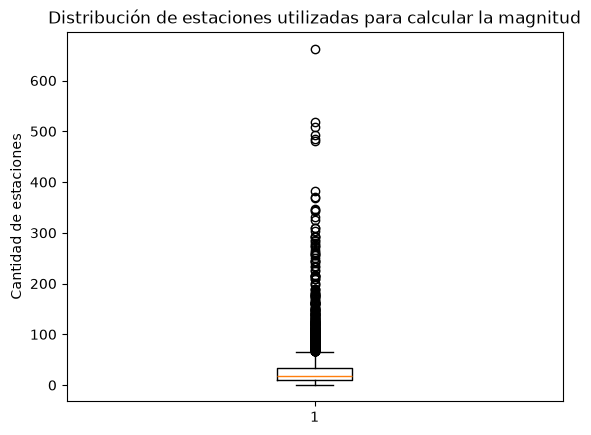

In [61]:
plt.boxplot(df_arg["magNst"].dropna())
plt.ylabel("Cantidad de estaciones")
plt.title("Distribución de estaciones utilizadas para calcular la magnitud")
plt.show()

**Figura 12. Participación de las estaciones en la determinación de la magnitud.**

El gráfico muestra la cantidad de estaciones sísmicas utilizadas para calcular la magnitud de los eventos. La distribución permite observar si la mayoría de las magnitudes se estimó con una cantidad similar de estaciones y detectar registros con valores excepcionalmente altos o bajos. Esta variable funciona como un indicador de calidad de la estimación de magnitud.

In [62]:
df_arg[(df_arg["magNst"]>=600)]

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,net,id,updated,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource
1092,2025-07-13T05:56:58.916Z,-24.1879,-66.7496,182.238,5.0,mb,75.0,48.0,1.798,1.11,us,us7000qcd6,2025-11-28T21:03:51.047Z,"43 km W of San Antonio de los Cobres, Argentina",earthquake,8.94,6.031,0.022,663.0,reviewed,us,us


Las variables de calidad, aunque presentan valores elevados, al analizarlas en detalle no se encuentran otras particularidades que hagan dudar de las observaciones, por lo que no se recomienda descartar datos.

# 8. Análisis espacial



<p align="center">
  <img src="https://github.com/fer-gif/proyecto_ypf/blob/main/imagenes/placas_tectonicas_sudamerica.png?raw=1" width="800">
</p>

<p align="center">
  <em>Figura 13. Contexto tectónico de América del Sur y regiones circundantes.</em><br>
  <em>Fuente: Modificado de Bird, 2003.</em>
</p>

Por lo que se observa al comparar las imágenes de los apartados 3 y 6.1 con la imagen anterior, se pueden distinguir tres zonas sísmicas principales. La primera corresponde a la subducción de las placas de Nazca y Antártica por debajo de las placas Sudamericana y de Scotia. La segunda se caracteriza por el movimiento transformante asociado a la placa de Scotia y por la presencia predominante de sismos de poca profundidad. Por último, se identifica una tercera zona correspondiente a la subducción de la placa Sudamericana por debajo de la placa de Sandwich. En las zonas de subducción se observa además un rango de profundidades mayor.


# 9. Análisis temporal


### 9.1 Evolución anual



In [63]:
horario = pd.to_datetime(df_arg['time']).dt.time
año = pd.to_datetime(df_arg['time']).dt.year
mes = pd.to_datetime(df_arg['time']).dt.month

time
2016     175
2017     502
2018     458
2019     433
2020     641
2021    1384
2022     771
2023     580
2024     538
2025     606
2026     343
Name: count, dtype: int64


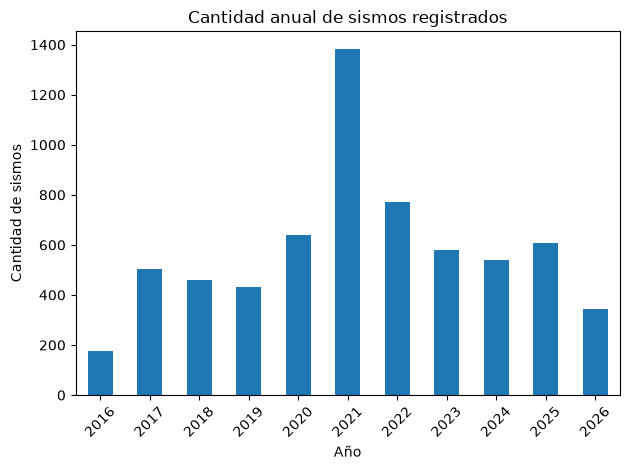

In [64]:

eventos_por_año = año.value_counts().sort_index()

print(eventos_por_año)

eventos_por_año.plot(kind="bar")

plt.xlabel("Año")
plt.ylabel("Cantidad de sismos")
plt.title("Cantidad anual de sismos registrados")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Figura 14. Variación de la actividad sísmica a lo largo del período analizado.**

El gráfico de barras muestra la cantidad de eventos registrados para cada año del período de estudio, permitiendo identificar variaciones interanuales y años con una mayor concentración de sismos. Particularmente, se observa una distribución anual bastante homogénea salvo para el año 2021 que se estudiará por separado.

### 9.2 Distribución mensual


time
1     509
2     381
3     430
4     464
5     555
6     435
7     451
8     983
9     617
10    587
11    494
12    525
Name: count, dtype: int64


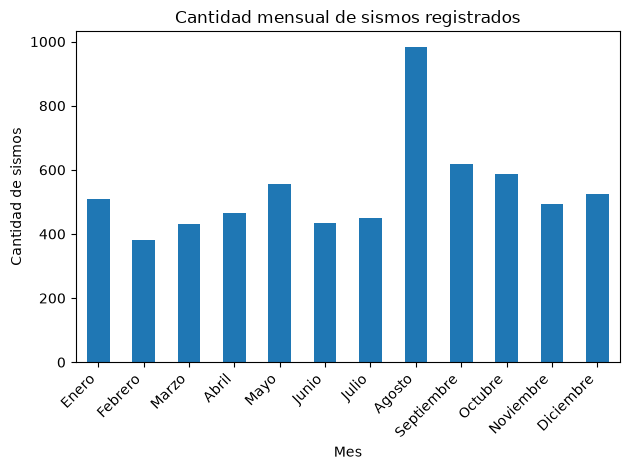

In [84]:
eventos_por_mes = mes.value_counts().sort_index()

print(eventos_por_mes)

nombres_meses = [
    "Enero", "Febrero", "Marzo", "Abril",
    "Mayo", "Junio", "Julio", "Agosto",
    "Septiembre", "Octubre", "Noviembre", "Diciembre"
]

eventos_por_mes.index = [nombres_meses[i - 1] for i in eventos_por_mes.index]

eventos_por_mes.plot(kind="bar")

plt.xlabel("Mes")
plt.ylabel("Cantidad de sismos")
plt.title("Cantidad mensual de sismos registrados")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Figura 15. Comportamiento de la actividad sísmica a lo largo del año.**

El gráfico de barras permite comparar la cantidad de eventos registrados en cada mes e identificar posibles variaciones en la actividad sísmica mensual. En particular, se observa una distribución mensual bastante homogénea salvo para el mes de agosto.
Se verá si este está relacionado con el pico del año 2021.

In [66]:
pd.crosstab(año, mes)

time,1,2,3,4,5,6,7,8,9,10,11,12
time,,,,,,,,,,,,
2016,0,0,0,0,0,0,0,0,41,48,52,34
2017,46,36,38,40,75,35,50,30,47,36,31,38
2018,17,19,34,48,40,33,41,30,51,52,58,35
2019,32,40,29,33,35,35,38,38,36,48,35,34
2020,41,40,41,61,47,47,44,40,66,95,58,61
2021,103,40,40,49,44,46,36,600,156,86,82,102
2022,84,57,80,89,70,55,54,54,58,55,55,60
2023,51,47,44,33,48,40,53,57,45,67,38,57
2024,59,33,33,44,67,49,44,41,54,31,33,50


Efectivamente hay un pico considerable para agosto de 2021, veremos cuál es la distribución espacial del fenómeno.

In [67]:

df_8_2021 = df_arg[(año == 2021) & (mes == 8)]

dia = pd.to_datetime(df_8_2021['time']).dt.day

gdf_8_2021 = gpd.GeoDataFrame(
    df_8_2021,
    geometry=gpd.points_from_xy(df_8_2021["longitude"], df_8_2021["latitude"]), crs="EPSG:4326"
)

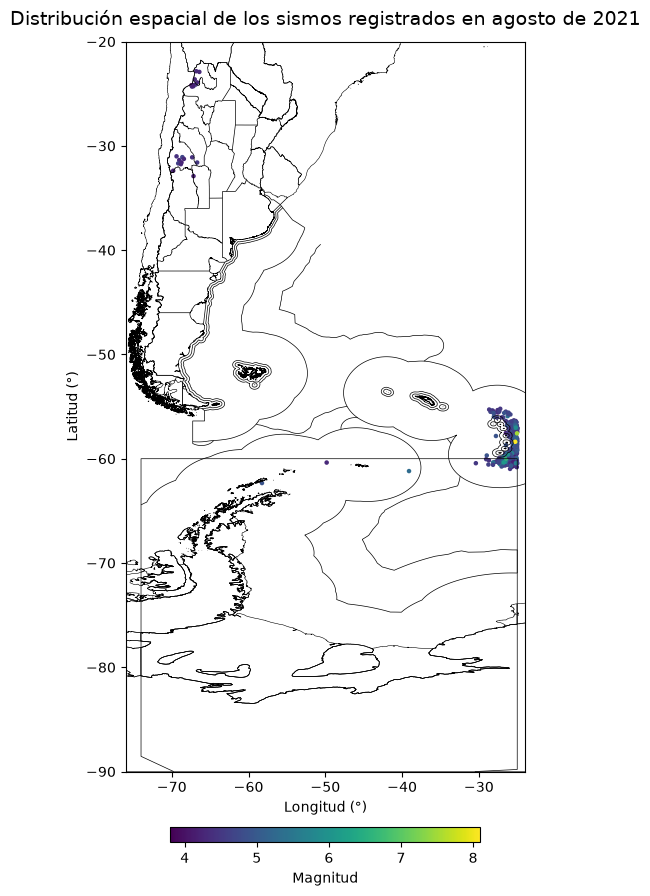

In [85]:

fig, ax = plt.subplots(figsize=(10, 12))

ign_sudam.plot(
    ax=ax,
    facecolor="none",
    edgecolor="black",
    linewidth=0.4
)

ign_arg.plot(
    ax=ax,
    color="black",
    linewidth=0.5
)

gdf_8_2021.plot(
    ax=ax,
    column="mag",
    cmap="viridis",
    markersize=5,
    legend=True,
    legend_kwds={"label": "Magnitud",
        "orientation": "horizontal",
        "shrink": 0.4,
        "pad": 0.06
    }
)

# Zoom sobre Argentina y alrededores
ax.set_xlim(-76, -24)
ax.set_ylim(-90, -20)

ax.set_xlabel("Longitud (°)")
ax.set_ylabel("Latitud (°)")
ax.set_title(
    "Distribución espacial de los sismos registrados en agosto de 2021",
    fontsize=14,
    pad=12
)

plt.show()

**Figura 16. Identificación de un episodio de actividad sísmica intensa.**

El mapa permite observar la concentración de eventos en el sector de las Islas Sandwich y diferenciar sus magnitudes mediante la escala de colores.


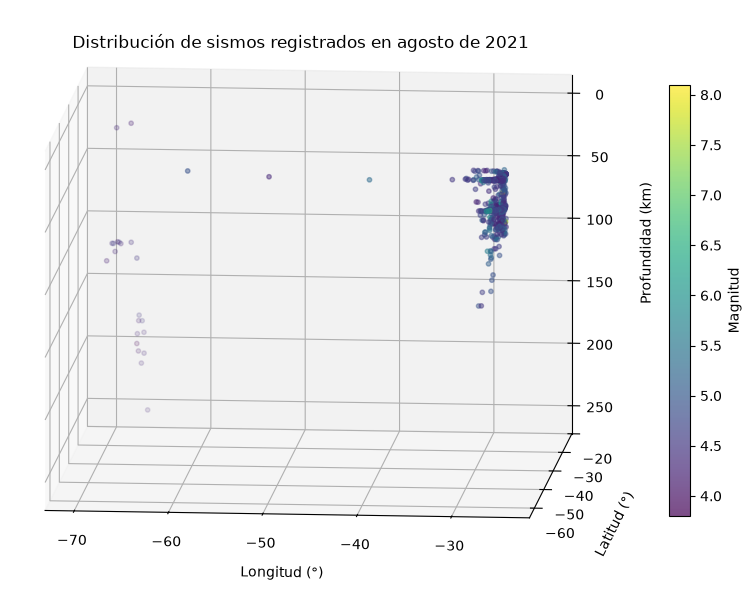

In [95]:

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    df_8_2021['longitude'],
    df_8_2021['latitude'],
    df_8_2021['depth'],
    c=df_8_2021['mag'],
    cmap='viridis',
    s=10,
    alpha=0.7
)

ax.set_xlabel('Longitud (°)', labelpad=8)
ax.set_ylabel('Latitud (°)', labelpad=8)
ax.set_zlabel('Profundidad (km)', labelpad=10)


# Ticks de latitud
ax.set_yticks([-60, -50, -40, -30, -20])


ax.invert_zaxis()

ax.view_init(elev=10, azim=-85)

# Perspectiva de los ticks
ax.set_proj_type('ortho')

ax.set_box_aspect(None, zoom=1.3)


ax.set_title(
    'Distribución de sismos registrados en agosto de 2021',
    y=1
)

fig.colorbar(
    scatter,
    ax=ax,
    label='Magnitud',
    shrink=0.7,
    pad=0.1
)

plt.show()

**Figura 17. Relación entre profundidad y magnitud de los eventos sísmicos.**

La representación tridimensional permite observar cómo se distribuyen los sismos según su ubicación y profundidad, mientras que la escala de colores indica la magnitud de cada evento.


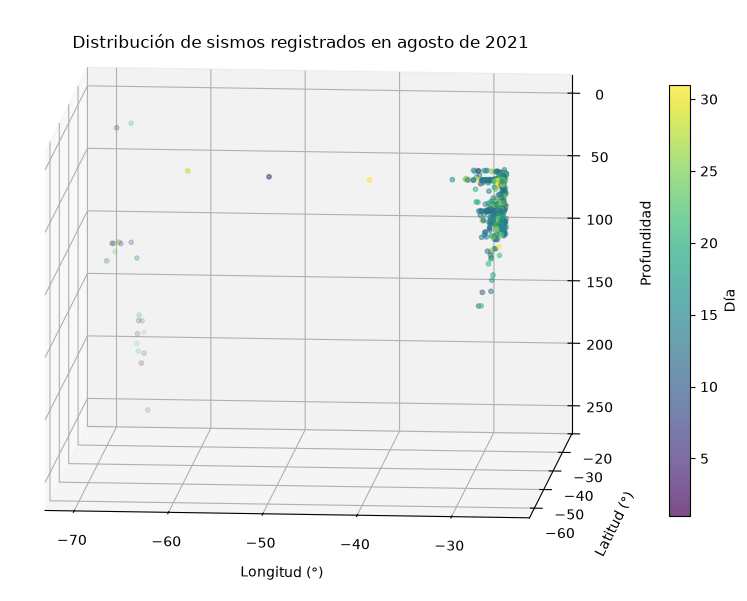

In [ ]:

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    df_8_2021['longitude'],
    df_8_2021['latitude'],
    df_8_2021['depth'],
    c=dia,
    cmap='viridis',
    s=10,
    alpha=0.7
)

ax.set_xlabel('Longitud (°)', labelpad=8)
ax.set_ylabel('Latitud (°)', labelpad=8)
ax.set_zlabel('Profundidad', labelpad=10)

ax.invert_zaxis()


# Ticks de latitud
ax.set_yticks([-60, -50, -40, -30, -20])


ax.view_init(elev=10, azim=-85)

# Perspectiva de los ticks
ax.set_proj_type('ortho')

ax.set_box_aspect(None, zoom=1.3)


ax.set_title(
    'Distribución de sismos registrados en agosto de 2021',
    y=1
)

fig.colorbar(
    scatter,
    ax=ax,
    label='Día',
    shrink=0.7,
    pad=0.1
)

plt.show()

**Figura 18. Evolución temporal del episodio sísmico durante el mes.**

La representación tridimensional permite identificar cómo se distribuyen los eventos en el espacio y la profundidad, mientras que la escala de colores indica el día de agosto en que ocurrió cada sismo.


A partir de las imágenes se observan cientos de sismos en la zona de las Islas Sandwich durante el período de estudio, destacándose un evento de magnitud aproximada 8. Al investigar este episodio, se identificó que corresponde a un sismo principal seguido por réplicas registradas durante las semanas posteriores en el mismo sector.


# 10. Requerimientos para la transformación


A partir de los resultados obtenidos durante la EDA, se establecen las siguientes decisiones para la preparación del conjunto de datos:

| Variable / elemento                       | Resultado de la EDA                                                                                             | Decisión                                                                       |
| ----------------------------------------- | --------------------------------------------------------------------------------------------------------------- | ------------------------------------------------------------------------------ |
| `time`                                    | Corresponde a la fecha y hora de ocurrencia de cada evento.                                                     | Convertir a tipo fecha (`datetime`) y crear nuevas columnas a partir de esta variable (año, mes, día, etc.).                                           |
| `latitude`                                | No presenta problemas que justifiquen su eliminación.                                                           | Conservar.                                                                     |
| `longitude`                               | No presenta problemas que justifiquen su eliminación.                                                           | Conservar.                                                                     |
| `depth`                                   | No se identificaron valores que por sí solos justificaran el descarte de registros.                             | Conservar.                                                                     |
| `mag`                                     | No se identificaron valores que por sí solos justificaran el descarte de registros.                             | Conservar.                                                                     |
| `magType`                                 | Aporta información sobre el método de cálculo de la magnitud.                                                   | Conservar.                                                                     |
| `nst`                                     | Presenta aproximadamente un 60 % de valores faltantes.                                                          | Descartar la variable.                                                         |
| `gap`                                     | Presenta una proporción muy baja de valores faltantes.                                                          | Imputar los valores faltantes mediante la mediana. |
| `dmin`                                    | Presenta una proporción muy baja de valores faltantes.                                                          | Imputar los valores faltantes mediante la mediana. |
| `rms`                                     | Presenta una proporción muy baja de valores faltantes y algunos valores elevados que no justifican el descarte. | Imputar los valores faltantes mediante la mediana. |
| `net`                                     | El 99,97 % de los registros corresponde a `us`.                                                                 | Descartar la variable por su escasa variabilidad.                              |
| `id`                                      | Identifica de manera única cada evento.                                                                         | Conservar.                                                                     |
| `updated`                                 | Contiene información temporal sobre la actualización del registro.                                              | Convertir a tipo fecha (`datetime`).                                           |
| `place`                                   | Contiene información textual sobre la ubicación.                                                                | Conservar.                                                                     |
| `type`                                    | El 100 % de los registros corresponde a `earthquake`.                                                           | Descartar la variable por no aportar variabilidad al conjunto.                 |
| `horizontalError`                         | Presenta una proporción muy baja de valores faltantes y algunos valores elevados que no justifican el descarte. | Imputar los valores faltantes mediante la mediana. |
| `depthError`                              | No presenta valores faltantes.                                                                                  | Conservar.                                                                     |
| `magError`                                | Presenta aproximadamente un 3,5 % de valores faltantes.                                                         | Imputar los valores faltantes mediante la mediana. |
| `magNst`                                  | Presenta aproximadamente un 3,6 % de valores faltantes.                                                         | Imputar los valores faltantes mediante la mediana. |
| `status`                                  | El 100 % de los registros corresponde a `reviewed`.                                                             | Descartar la variable por no aportar variabilidad al conjunto.                 |
| `locationSource`                          | El 99,9 % de los registros corresponde a `us`.                                                                  | Descartar la variable por su escasa variabilidad.                              |
| `magSource`                               | El 96,5 % de los registros corresponde a `us`.                                                                  | Descartar la variable por su escasa variabilidad.                              |
| Registros con múltiples valores faltantes | Se identificaron cuatro registros con cinco o más variables de calidad faltantes.                               | Descartar los registros identificados por "id": [iscgem621613005, iscgem620210242, us10007f0t, us100073ln].                                         |


# 11. Conclusiones de la EDA
La EDA permitió conocer las principales características del conjunto de datos e identificar algunos aspectos relevantes para el análisis. Los valores faltantes se concentran principalmente en las variables de calidad, y se identificaron algunos registros con varias de estas métricas ausentes. En cuanto a magnitud y profundidad, no se encontraron valores que por sí solos justificaran el descarte de registros. Por otro lado, el análisis temporal mostró una variación importante durante 2021, principalmente por el aumento de eventos registrado en agosto, concentrados en la zona de las Islas Sandwich. En conjunto, estos resultados permitieron identificar las principales características y particularidades del conjunto de datos.
